In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from opencv_tools import opencv_tools

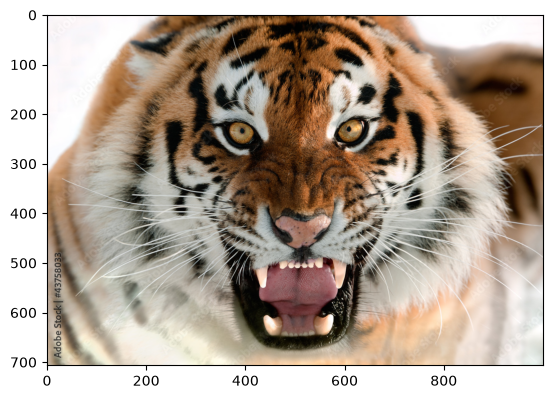

In [6]:
file_name = '../dataset/img/tiger.jpg'
img = cv2.imread(filename=file_name)
img = cv2.cvtColor(src=img, code=cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

In [16]:
# Img information
img.shape, img.size, img.dtype

((707, 1000, 3), 2121000, dtype('uint8'))

### The Meaning of (B, G, R)

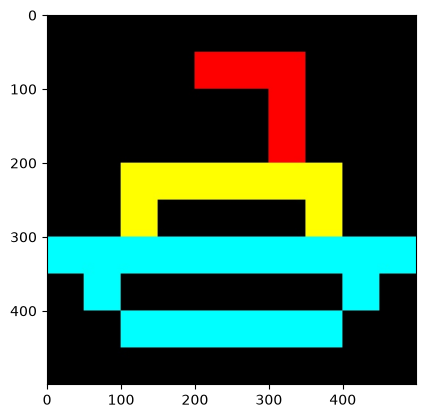

In [8]:
img = cv2.imread('../dataset/img/colored_boat.jpg')
opencv_tools.show_img_by_matplotlib(img)

In [9]:
B, G, R = cv2.split(img)

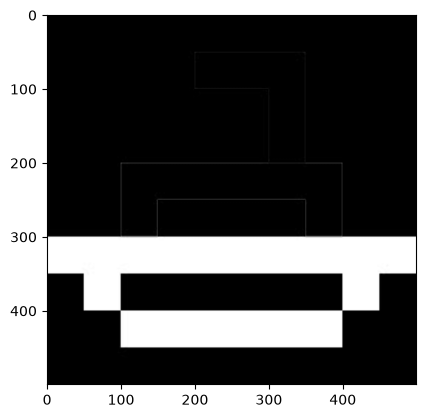

In [10]:
opencv_tools.show_img_by_matplotlib(B)

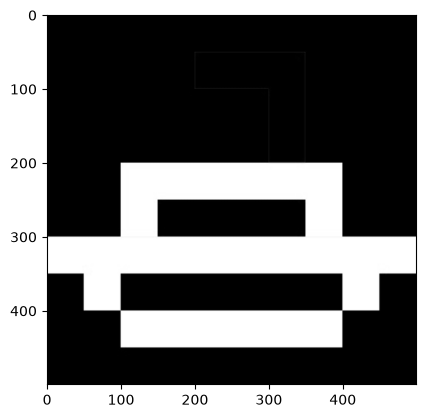

In [11]:
opencv_tools.show_img_by_matplotlib(G)

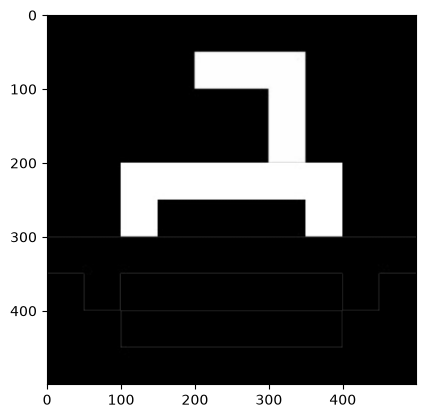

In [12]:
opencv_tools.show_img_by_matplotlib(R)

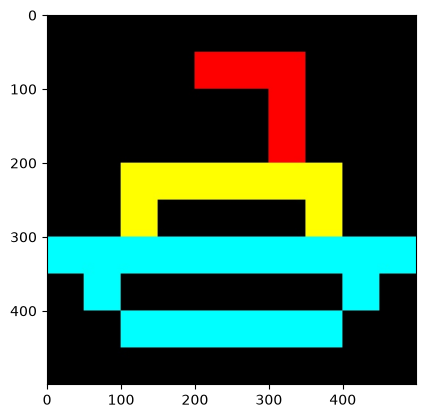

In [13]:
merged_color = cv2.merge([B, G, R])
opencv_tools.show_img_by_matplotlib(merged_color)

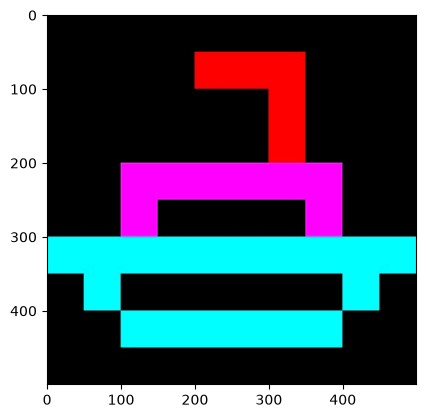

In [15]:
merged_image_wrong = cv2.merge([G, B, R]) #搞錯順序顯示
opencv_tools.show_img_by_matplotlib(merged_image_wrong)

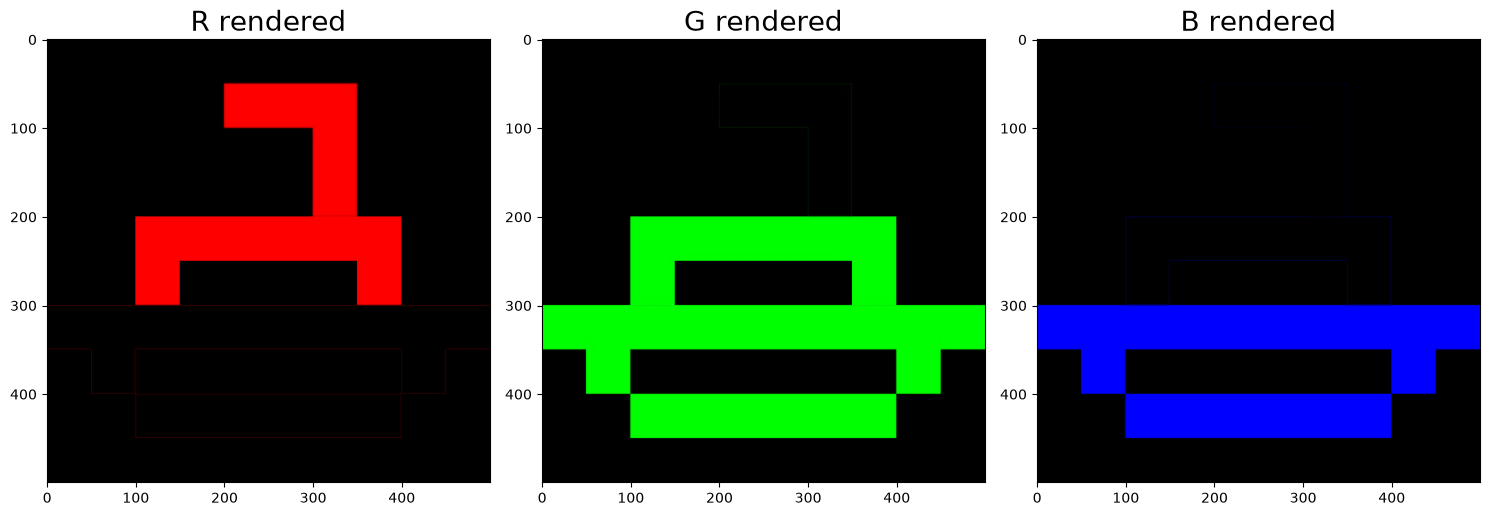

In [20]:
zeros = np.zeros(img.shape[:2], dtype=np.uint8)

R_renderred = cv2.merge([zeros, zeros, R])
G_renderred = cv2.merge([zeros, G, zeros])
B_renderred = cv2.merge([B, zeros, zeros])

opencv_tools.show_img_by_matplotlib_1x3(
    "R rendered", R_renderred, 
    "G rendered", G_renderred, 
    "B rendered", B_renderred)

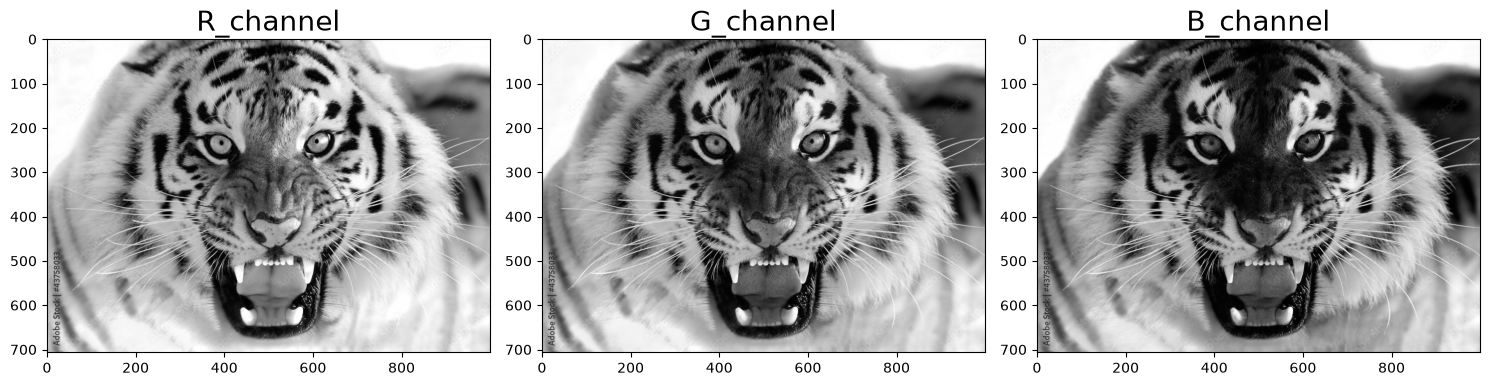

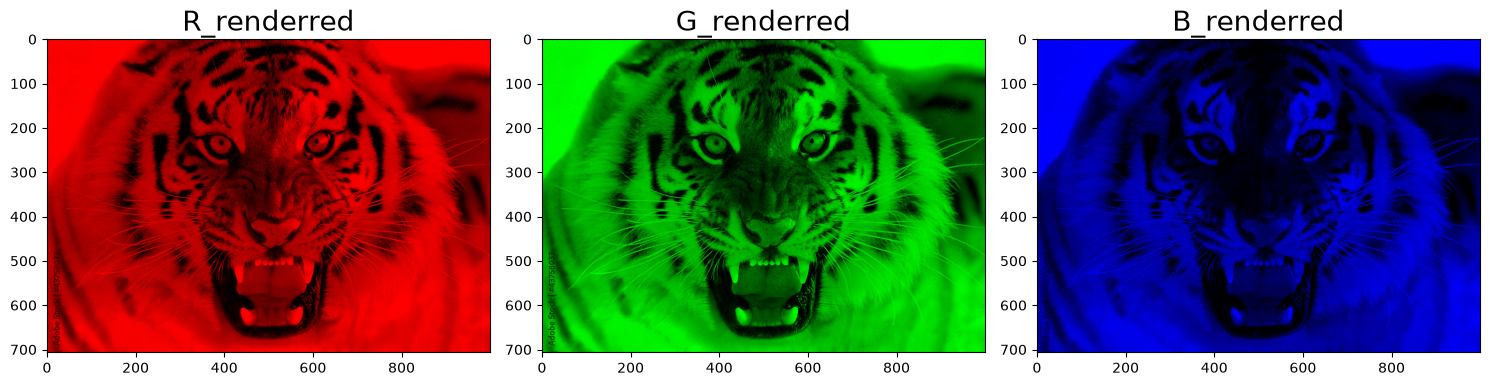

In [3]:
file_name = '../dataset/img/tiger.jpg'
img = cv2.imread(filename=file_name)
B, G, R = cv2.split(img)

zeros = np.zeros(img.shape[:2], dtype=np.uint8)

opencv_tools.show_img_by_matplotlib_1x3(
    "R_channel", R,
    "G_channel", G,
    "B_channel", B
)

R_renderred = cv2.merge([zeros, zeros, R])
G_renderred = cv2.merge([zeros, G, zeros])
B_renderred = cv2.merge([B, zeros, zeros])

opencv_tools.show_img_by_matplotlib_1x3(
    "R_renderred", R_renderred,
    "G_renderred", G_renderred,
    "B_renderred", B_renderred
)


### Gray Scale

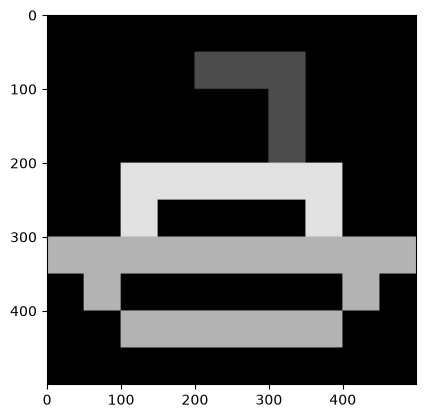

In [18]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
opencv_tools.show_img_by_matplotlib(gray)

### The histogram of (R, G, B)

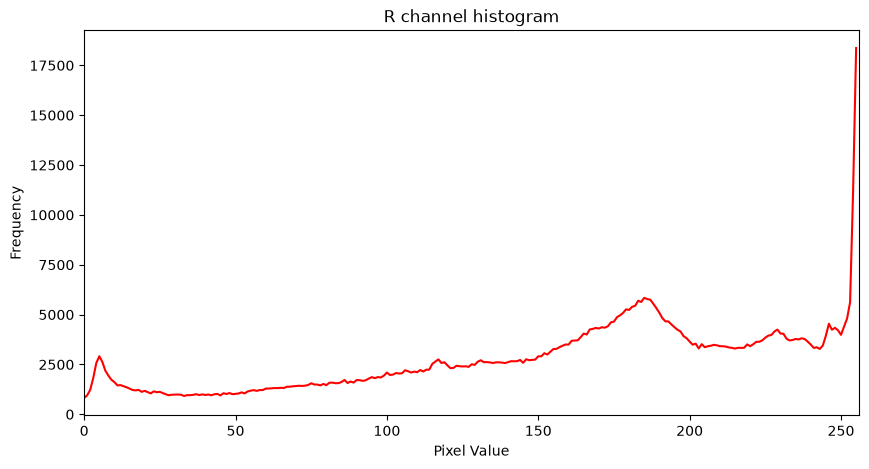

In [6]:
plt.figure(figsize=(10, 5))
histogram = cv2.calcHist(images=[img], channels=[2], mask=None, histSize=[256], ranges=[0, 256])
plt.plot(histogram, color='red')
plt.title('R channel histogram')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.xlim([0, 256])
plt.show()

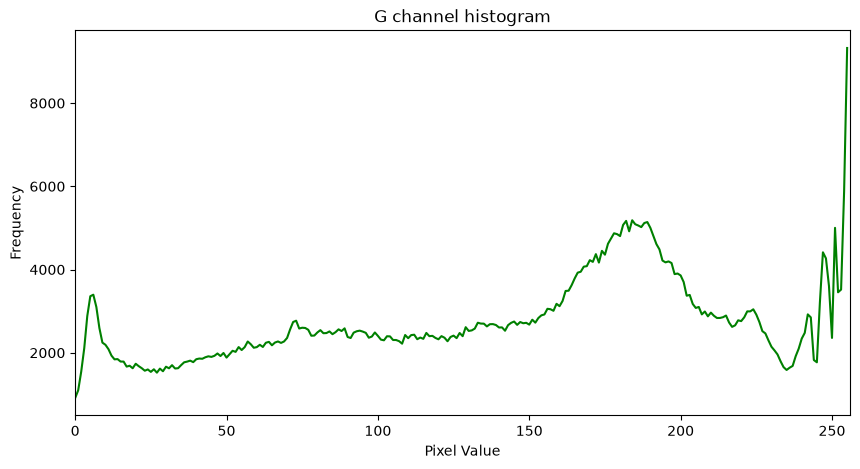

In [7]:
plt.figure(figsize=(10, 5))
histogram = cv2.calcHist(images=[img], channels=[1], mask=None, histSize=[256], ranges=[0, 256])
plt.plot(histogram, color='green')
plt.title('G channel histogram')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.xlim([0, 256])
plt.show()

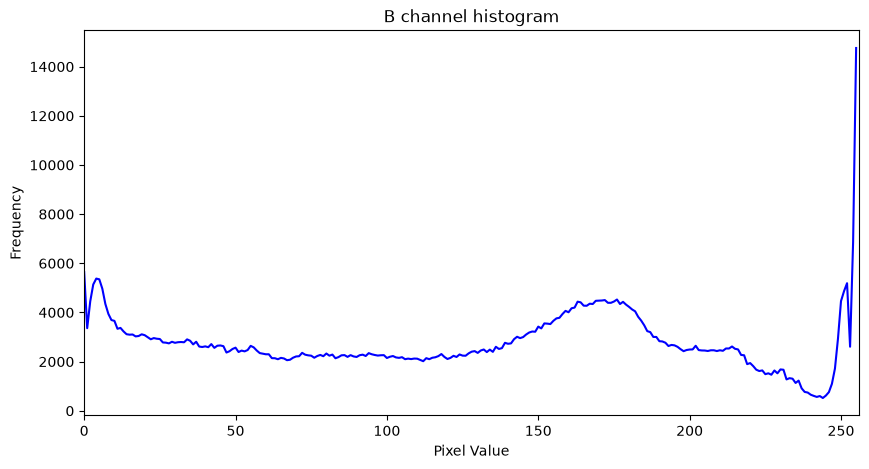

In [8]:
plt.figure(figsize=(10, 5))
histogram = cv2.calcHist(images=[img], channels=[0], mask=None, histSize=[256], ranges=[0, 256])
plt.plot(histogram, color='blue')
plt.title('B channel histogram')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.xlim([0, 256])
plt.show()

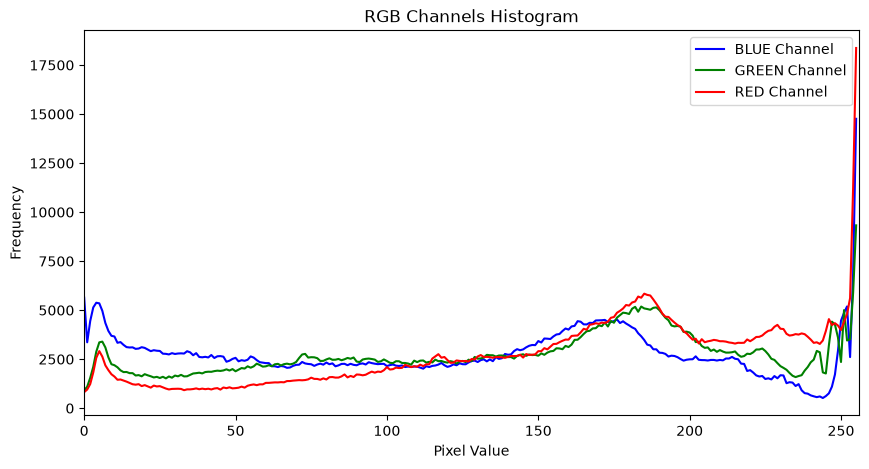

In [9]:
colors = ('blue', 'green', 'red')
plt.figure(figsize=(10, 5))
for i, color in enumerate(colors):
    histogram = cv2.calcHist(images=[img], channels=[i], mask=None, histSize=[256], ranges=[0, 256])
    plt.plot(histogram, color=color, label=f"{color.upper()} Channel")
plt.title("RGB Channels Histogram")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.xlim([0, 256])
plt.legend()  # 顯示圖例
plt.show()

### HSV Implementation

In [10]:
hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

In [11]:
lower_red1 = np.array([0, 0, 0])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 0, 0])
upper_red2 = np.array([179, 255, 255])

In [12]:
mask1 = cv2.inRange(hsv_img, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv_img, lower_red2, upper_red2)

In [13]:
red_mask = cv2.bitwise_or(mask1, mask2)

In [14]:
red_result = cv2.bitwise_and(img, img, mask=red_mask)

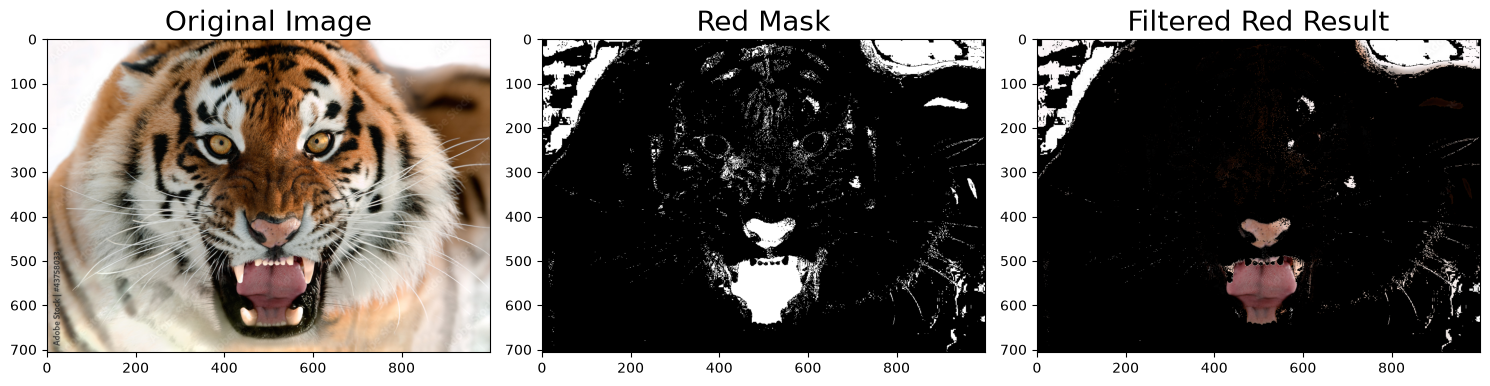

In [15]:
opencv_tools.show_img_by_matplotlib_1x3(
    'Original Image', img,
    'Red Mask', red_mask,
    'Filtered Red Result', red_result,
)